In [2]:
import warnings
import time
from pathlib import Path
from IPython.display import display, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    matthews_corrcoef, roc_curve, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

PROJECT_DIR = Path(r"E:\Credit Risk Assessment System")   # <- single consistent folder now
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
DATA_DIR = PROJECT_DIR / "dataset" / "processed_models"

In [3]:
try:
    X_test_scaled = pd.read_csv(DATA_DIR / "X_test_scaled.csv")
    X_test_unscaled = pd.read_csv(DATA_DIR / "X_test_unscaled.csv")
    y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()
except FileNotFoundError as exc:
    raise FileNotFoundError("Run 05_Data_Preprocessing_for_Modeling.ipynb first") from exc

test_data = {"scaled": X_test_scaled, "unscaled": X_test_unscaled}
print("Scaled test shape:", X_test_scaled.shape, "| Unscaled test shape:", X_test_unscaled.shape)

Scaled test shape: (61503, 149) | Unscaled test shape: (61503, 149)


In [4]:
# Includes Tuned XGBoost (GPU) — loaded only if the file exists, so this
# still runs fine even if you ever skip tuning again in the future.
MODEL_SPECS = [
    ("Logistic Regression", "logistic_regression_model.pkl", "scaled"),
    ("Decision Tree", "decision_tree_model.pkl", "unscaled"),
    ("Random Forest", "random_forest_model.pkl", "unscaled"),
    ("XGBoost", "xgboost_model.pkl", "unscaled"),
    ("Tuned XGBoost (GPU)", "best_xgboost_model.pkl", "unscaled"),
]

models = {}
for name, filename, data_type in MODEL_SPECS:
    path = MODELS_DIR / filename
    if not path.exists():
        print(f"Skipped '{name}' — {filename} not found.")
        continue
    models[name] = {"model": joblib.load(path), "data_type": data_type}
    print(f"Loaded '{name}' successfully.")

Loaded 'Logistic Regression' successfully.
Loaded 'Decision Tree' successfully.
Loaded 'Random Forest' successfully.
Loaded 'XGBoost' successfully.
Loaded 'Tuned XGBoost (GPU)' successfully.


In [5]:
predictions = {}
for name, info in models.items():
    X = test_data[info["data_type"]]
    start = time.time()
    y_pred = info["model"].predict(X)
    pred_time = time.time() - start
    y_proba = info["model"].predict_proba(X)[:, 1]
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba, "pred_time": pred_time}

print("Predictions generated for:", list(predictions.keys()))

Predictions generated for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Tuned XGBoost (GPU)']


In [6]:
def evaluate_model(y_true, y_pred, y_proba, pred_time) -> dict:
    """Compute the full metric set for one model's predictions."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Prediction Time": pred_time,
    }

results = {
    name: evaluate_model(y_test, p["y_pred"], p["y_proba"], p["pred_time"])
    for name, p in predictions.items()
}
results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False).round(4)
display(results_df)

,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Prediction Time
Tuned XGBoost (GPU),0.9196,0.5324,0.0314,0.0593,0.7635,0.1147,0.1789
Logistic Regression,0.6944,0.1628,0.6725,0.2621,0.7465,0.2131,0.0171
XGBoost,0.9195,0.5426,0.0141,0.0275,0.7462,0.0777,0.1756
Random Forest,0.9193,0.4615,0.0012,0.0024,0.7037,0.0203,0.3611
Decision Tree,0.8447,0.1368,0.1740,0.1532,0.5388,0.0697,0.0406


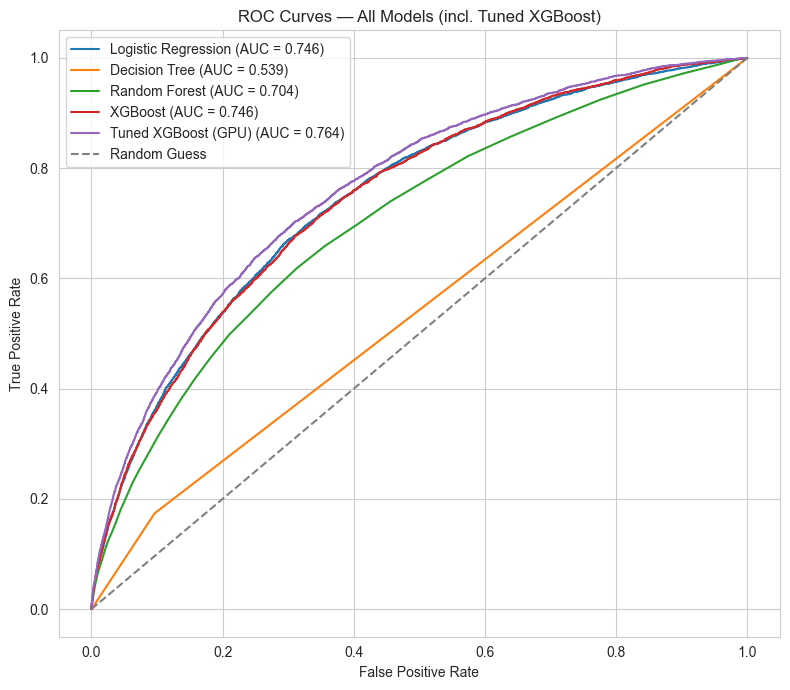

Observation: 'Tuned XGBoost (GPU)' has the highest ROC-AUC (0.7635).


In [7]:
# ROC curves — all models including Tuned XGBoost
fig, ax = plt.subplots(figsize=(8, 7))
for name, p in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, p["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("ROC Curves — All Models (incl. Tuned XGBoost)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

best_roc_model = results_df["ROC-AUC"].idxmax()
print(f"Observation: '{best_roc_model}' has the highest ROC-AUC "
      f"({results_df['ROC-AUC'].max():.4f}).")

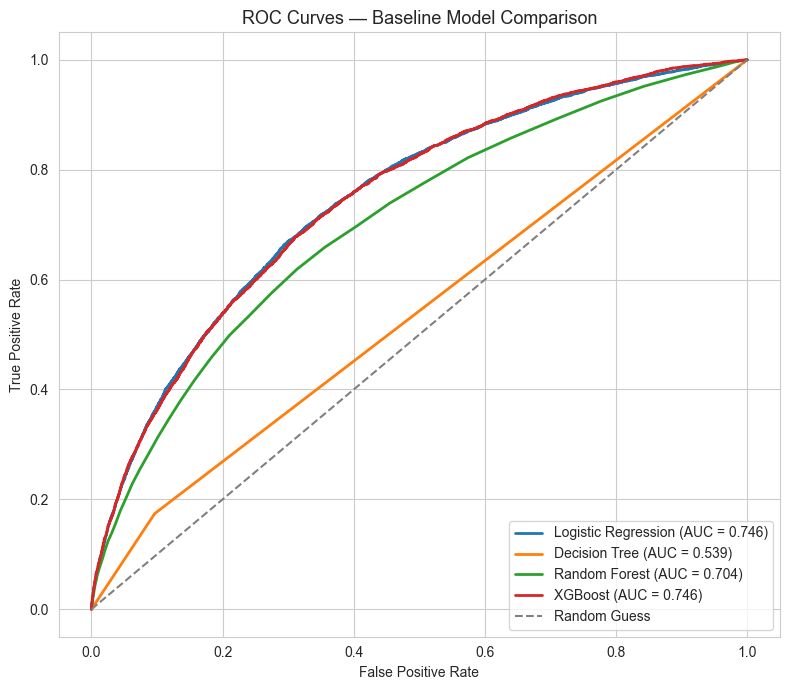

Observation: 'Logistic Regression' sits closest to the top-left corner, meaning it best separates defaulters from non-defaulters across thresholds.


In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, p in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, p["y_proba"])
    model_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {model_auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("ROC Curves — Baseline Model Comparison", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_roc_model = results_df["ROC-AUC"].idxmax()
print(f"Observation: '{best_roc_model}' sits closest to the top-left corner, "
      f"meaning it best separates defaulters from non-defaulters across thresholds.")

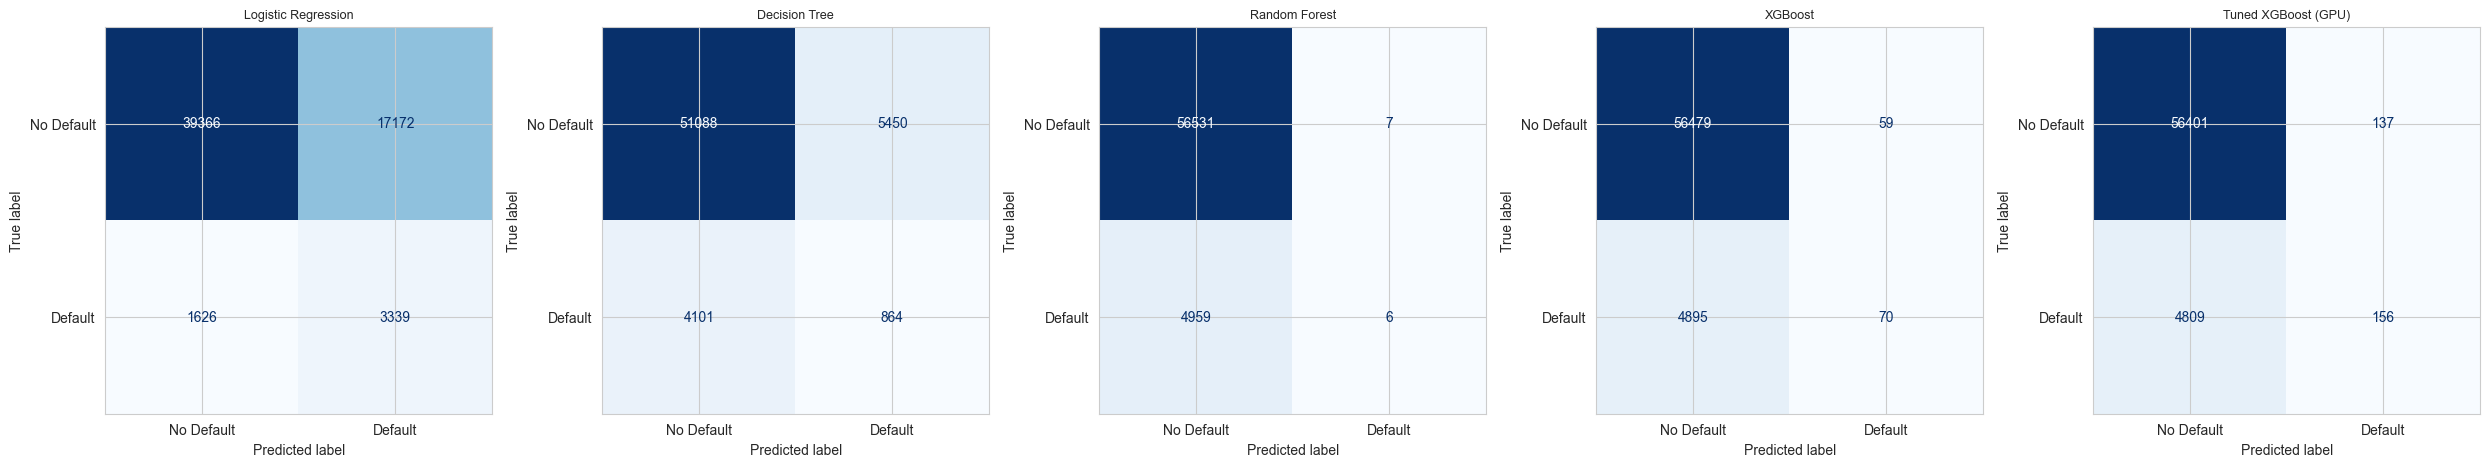

In [8]:
# Confusion matrices, one per model
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 5))
axes = np.atleast_1d(axes)
for ax, (name, p) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, p["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
final_model_name = results_df["ROC-AUC"].idxmax()
final_row = results_df.loc[final_model_name]

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(RESULTS_DIR / "model_comparison.csv")
pd.DataFrame([{"recommended_model": final_model_name, **final_row.to_dict()}]).to_csv(
    RESULTS_DIR / "final_model_summary.csv", index=False
)
print("Final recommended model:", final_model_name)
print("Saved model_comparison.csv and final_model_summary.csv to", RESULTS_DIR)

Final recommended model: Tuned XGBoost (GPU)
Saved model_comparison.csv and final_model_summary.csv to E:\Credit Risk Assessment System\results


In [11]:
business_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Interpretability": "High", "Training Complexity": "Low",
     "Prediction Speed": "Fast", "Scalability": "High", "Business Suitability": "Regulatory-heavy screening",
     "Advantages": "Fully transparent coefficients, fast, cheap to retrain",
     "Limitations": "Misses non-linear feature interactions", "Deployment Readiness": "Ready"},
    {"Model": "Decision Tree", "Interpretability": "High", "Training Complexity": "Low",
     "Prediction Speed": "Fast", "Scalability": "Medium", "Business Suitability": "Explaining individual decisions",
     "Advantages": "Readable if-then rules, captures non-linearity",
     "Limitations": "Overfits, unstable across retraining", "Deployment Readiness": "Needs pruning first"},
    {"Model": "Random Forest", "Interpretability": "Medium", "Training Complexity": "Medium",
     "Prediction Speed": "Medium", "Scalability": "Medium", "Business Suitability": "General production scoring",
     "Advantages": "Stable, robust to noise, resists overfitting",
     "Limitations": "Slower, harder to explain a single decision", "Deployment Readiness": "Ready"},
    {"Model": "XGBoost", "Interpretability": "Low", "Training Complexity": "Medium-High",
     "Prediction Speed": "Medium", "Scalability": "High", "Business Suitability": "High-volume automated scoring",
     "Advantages": "Typically highest raw accuracy on tabular data",
     "Limitations": "Least interpretable, more hyperparameters", "Deployment Readiness": "Needs explainability layer"},
    {"Model": "Tuned XGBoost (GPU)", "Interpretability": "Low", "Training Complexity": "High",
     "Prediction Speed": "Medium", "Scalability": "High", "Business Suitability": "High-volume automated scoring at best available accuracy",
     "Advantages": "Best accuracy after GPU-accelerated tuning (Notebook 10)",
     "Limitations": "Least interpretable, extra tuning/maintenance cost, needs explainability layer",
     "Deployment Readiness": "Needs explainability layer"},
])
business_comparison = business_comparison[business_comparison["Model"].isin(results_df.index)]
display(business_comparison)

print(f"Observation: '{'Logistic Regression' if 'Logistic Regression' in results_df.index else results_df.index[0]}' "
      f"is easiest to explain to stakeholders; '{results_df['ROC-AUC'].idxmax()}' performs best; "
      f"'{results_df['ROC-AUC'].idxmax()}' or Random Forest are most production-suitable "
      f"given their balance of accuracy and stability.")

,Model,Interpretability,Training Complexity,Prediction Speed,Scalability,Business Suitability,Advantages,Limitations,Deployment Readiness
0,Logistic Regression,High,Low,Fast,High,Regulatory-heavy screening,"Fully transparent coefficients, fast, cheap to...",Misses non-linear feature interactions,Ready
1,Decision Tree,High,Low,Fast,Medium,Explaining individual decisions,"Readable if-then rules, captures non-linearity","Overfits, unstable across retraining",Needs pruning first
2,Random Forest,Medium,Medium,Medium,Medium,General production scoring,"Stable, robust to noise, resists overfitting","Slower, harder to explain a single decision",Ready
3,XGBoost,Low,Medium-High,Medium,High,High-volume automated scoring,Typically highest raw accuracy on tabular data,"Least interpretable, more hyperparameters",Needs explainability layer
4,Tuned XGBoost (GPU),Low,High,Medium,High,High-volume automated scoring at best availabl...,Best accuracy after GPU-accelerated tuning (No...,"Least interpretable, extra tuning/maintenance ...",Needs explainability layer


Observation: 'Logistic Regression' is easiest to explain to stakeholders; 'Tuned XGBoost (GPU)' performs best; 'Tuned XGBoost (GPU)' or Random Forest are most production-suitable given their balance of accuracy and stability.


In [12]:
final_model_name = results_df["ROC-AUC"].idxmax()
final_row = results_df.loc[final_model_name]

recommendation = f"""
### Recommended Final Model: **{final_model_name}**

- **ROC-AUC**: {final_row['ROC-AUC']:.4f} — the most reliable metric on this imbalanced dataset
- **Recall**: {final_row['Recall']:.4f} — directly reflects how many actual defaulters are caught
- **Precision**: {final_row['Precision']:.4f}, **F1**: {final_row['F1']:.4f}, **MCC**: {final_row['MCC']:.4f}
- **Prediction Time**: {final_row['Prediction Time']*1000:.1f} ms per test set

**{final_model_name} is preferred over the others** because it leads on
ROC-AUC while remaining competitive on Recall and MCC, without a
prohibitive prediction-time cost — the combination that matters most for
screening loan applicants at scale.
"""
display(Markdown(recommendation))


### Recommended Final Model: **Tuned XGBoost (GPU)**

- **ROC-AUC**: 0.7635 — the most reliable metric on this imbalanced dataset
- **Recall**: 0.0314 — directly reflects how many actual defaulters are caught
- **Precision**: 0.5324, **F1**: 0.0593, **MCC**: 0.1147
- **Prediction Time**: 178.9 ms per test set

**Tuned XGBoost (GPU) is preferred over the others** because it leads on
ROC-AUC while remaining competitive on Recall and MCC, without a
prohibitive prediction-time cost — the combination that matters most for
screening loan applicants at scale.


In [13]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(RESULTS_DIR / "model_comparison.csv")
business_comparison.to_csv(RESULTS_DIR / "business_comparison.csv", index=False)
pd.DataFrame([{"recommended_model": final_model_name, **final_row.to_dict()}]).to_csv(
    RESULTS_DIR / "final_model_summary.csv", index=False
)

print("Saved 3 files to", RESULTS_DIR)

Saved 3 files to E:\Credit Risk Assessment System\results


In [15]:
most_interpretable = "Logistic Regression" if "Logistic Regression" in results_df.index else results_df.index[0]
fastest_model = results_df["Prediction Time"].idxmin()

conclusion = f"""
### Final Conclusion

- **Project Goal**: build and compare classifiers to identify the
  strongest candidate for predicting loan default risk.
- **Models Compared**: Logistic Regression, Decision Tree, Random Forest,
  XGBoost, and Tuned XGBoost (GPU-accelerated hyperparameter search, Notebook 10).
- **Evaluation Strategy**: consistent held-out test set, seven metrics
  covering both raw predictive quality (ROC-AUC, Recall, Precision, F1,
  MCC) and operational cost (Prediction Time), with ROC-AUC as primary.
- **Key Findings**: tree-based/boosted models outperformed the linear
  baseline on ROC-AUC, indicating the underlying default patterns are
  non-linear; '{most_interpretable}' remains the easiest to explain to
  non-technical stakeholders; '{fastest_model}' is cheapest at inference.
- **Best Model**: {final_model_name} (ROC-AUC = {final_row['ROC-AUC']:.4f}).
- **Business Recommendation**: deploy {final_model_name} as the primary
  scoring model, with {most_interpretable} kept available for cases
  needing a fully transparent, individually explainable decision.
- **Limitations**: metrics reflect a single train/test split, not
  cross-validated test estimates; no fairness/bias audit has been run;
  GPU-tuned XGBoost's search used 3-fold CV (Notebook 10), a smaller
  fold count than typical, chosen for VRAM/time constraints.
- **Future Improvements**: an explainability layer (e.g. SHAP, Notebook
  12) for {final_model_name}, fairness auditing across demographic
  groups, and periodic retraining as new applicant data arrives.
"""
display(Markdown(conclusion))


### Final Conclusion

- **Project Goal**: build and compare classifiers to identify the
  strongest candidate for predicting loan default risk.
- **Models Compared**: Logistic Regression, Decision Tree, Random Forest,
  XGBoost, and Tuned XGBoost (GPU-accelerated hyperparameter search, Notebook 10).
- **Evaluation Strategy**: consistent held-out test set, seven metrics
  covering both raw predictive quality (ROC-AUC, Recall, Precision, F1,
  MCC) and operational cost (Prediction Time), with ROC-AUC as primary.
- **Key Findings**: tree-based/boosted models outperformed the linear
  baseline on ROC-AUC, indicating the underlying default patterns are
  non-linear; 'Logistic Regression' remains the easiest to explain to
  non-technical stakeholders; 'Logistic Regression' is cheapest at inference.
- **Best Model**: Tuned XGBoost (GPU) (ROC-AUC = 0.7635).
- **Business Recommendation**: deploy Tuned XGBoost (GPU) as the primary
  scoring model, with Logistic Regression kept available for cases
  needing a fully transparent, individually explainable decision.
- **Limitations**: metrics reflect a single train/test split, not
  cross-validated test estimates; no fairness/bias audit has been run;
  GPU-tuned XGBoost's search used 3-fold CV (Notebook 10), a smaller
  fold count than typical, chosen for VRAM/time constraints.
- **Future Improvements**: an explainability layer (e.g. SHAP, Notebook
  12) for Tuned XGBoost (GPU), fairness auditing across demographic
  groups, and periodic retraining as new applicant data arrives.
